In [1]:
# General purpose
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Signal processing
from scipy.io import loadmat 
from scipy.ndimage import convolve1d
from scipy.signal import butter
from scipy.signal import sosfiltfilt
from scipy.signal import welch

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
# Hyperparameter tuning
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
# Feature selection
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import SelectKBest

np.random.seed(42)

In [2]:
MOV_MEAN_LENGTH = 100

In [14]:
SUBJECT_IDS = range(1, 28)
filepath_mat_list = [f"data/S{str(i)}_A1_E1.mat" for i in SUBJECT_IDS]

print(filepath_mat_list)


['data/S1_A1_E1.mat', 'data/S2_A1_E1.mat', 'data/S3_A1_E1.mat', 'data/S4_A1_E1.mat', 'data/S5_A1_E1.mat', 'data/S6_A1_E1.mat', 'data/S7_A1_E1.mat', 'data/S8_A1_E1.mat', 'data/S9_A1_E1.mat', 'data/S10_A1_E1.mat', 'data/S11_A1_E1.mat', 'data/S12_A1_E1.mat', 'data/S13_A1_E1.mat', 'data/S14_A1_E1.mat', 'data/S15_A1_E1.mat', 'data/S16_A1_E1.mat', 'data/S17_A1_E1.mat', 'data/S18_A1_E1.mat', 'data/S19_A1_E1.mat', 'data/S20_A1_E1.mat', 'data/S21_A1_E1.mat', 'data/S22_A1_E1.mat', 'data/S23_A1_E1.mat', 'data/S24_A1_E1.mat', 'data/S25_A1_E1.mat', 'data/S26_A1_E1.mat', 'data/S27_A1_E1.mat']


In [17]:
data_list = []

for subject_id, filepath in zip(SUBJECT_IDS, filepath_mat_list):
    mat = loadmat(filepath)
    # keep only user keys
    mat = {key: mat[key] for key in mat.keys() if not key.startswith('__')}

    # EMG is a 2D array (n_samples, n_channels). Ensure it is 2D.
    emg = np.asarray(mat.get('emg'))
    n_samples, n_channels = emg.shape
    
    print(f"Subject {subject_id}: EMG data dimension: {emg.shape}")

    # helper to get 1D arrays for other signals
    def to_1d(key, length=n_samples):
        arr = mat.get(key, np.zeros((length,)))
        arr = np.asarray(arr).squeeze()
        if arr.ndim != 1:
            arr = arr.ravel()
        return arr

    stimulus = to_1d('stimulus')
    restimulus = to_1d('restimulus')
    repetition = to_1d('repetition')
    rerepetition = to_1d('rerepetition')

    # build a dataframe where each EMG channel is its own column (1D each)
    emg_cols = {f'emg_ch{ch+1}': emg[:, ch] for ch in range(n_channels)}
    df = pd.DataFrame(emg_cols)
    df['stimulus'] = stimulus
    df['restimulus'] = restimulus
    df['repetition'] = repetition
    df['rerepetition'] = rerepetition
    df['subject_id'] = subject_id

    data_list.append(df)

# concatenate all subjects' data (each column is 1D)
all_data = pd.concat(data_list, ignore_index=True)
print(all_data.head())


Subject 1: EMG data dimension: (101014, 10)
Subject 2: EMG data dimension: (100686, 10)
Subject 3: EMG data dimension: (100720, 10)
Subject 4: EMG data dimension: (100835, 10)
Subject 5: EMG data dimension: (100894, 10)
Subject 6: EMG data dimension: (101083, 10)
Subject 7: EMG data dimension: (100817, 10)
Subject 8: EMG data dimension: (100854, 10)
Subject 9: EMG data dimension: (100925, 10)
Subject 10: EMG data dimension: (100778, 10)
Subject 11: EMG data dimension: (100899, 10)
Subject 12: EMG data dimension: (100920, 10)
Subject 13: EMG data dimension: (100948, 10)
Subject 14: EMG data dimension: (100785, 10)
Subject 15: EMG data dimension: (101508, 10)
Subject 16: EMG data dimension: (101191, 10)
Subject 17: EMG data dimension: (101675, 10)
Subject 18: EMG data dimension: (101323, 10)
Subject 19: EMG data dimension: (101299, 10)
Subject 20: EMG data dimension: (101565, 10)
Subject 21: EMG data dimension: (101732, 10)
Subject 22: EMG data dimension: (101884, 10)
Subject 23: EMG dat

## Data Inspection

In [ ]:

for subject_id in SUBJECT_IDS:
    subject_data = all_data[all_data['subject_id'] == subject_id]
    print(f"Subject {subject_id} data shape: {subject_data.shape}")

    emg = subject_data[[col for col in subject_data.columns if col.startswith('emg_ch')]].values
    print("EMG data dimension: {}".format(emg.shape))
    print("EMG data type: {}".format(type(emg)))

    # convert pandas Series to numpy arrays to allow numpy boolean indexing
    stimulus = subject_data['restimulus'].to_numpy()
    repetition = subject_data['rerepetition'].to_numpy()

    n_stimuli = len(np.unique(stimulus)) - 1 # -1 because 0 is the resting condition
    n_repetitions = len(np.unique(repetition)) - 1 # -1 because 0 is not a repetition
    n_channels = emg.shape[1]

    mov_mean_weights = np.ones(MOV_MEAN_LENGTH) / MOV_MEAN_LENGTH

    #initializing the data structure
    emg_windows = [[None for repetition_idx in range(n_repetitions)] for stimuli_idx in range(n_stimuli)] 
    emg_envelopes = [[None for repetition_idx in range(n_repetitions)] for stimuli_idx in range(n_stimuli)]

    for stimuli_idx in range(n_stimuli):
        for repetition_idx in range(n_repetitions):
            # boolean mask as a numpy array (no .flatten() needed)
            idx = np.logical_and(stimulus == stimuli_idx + 1, repetition == repetition_idx + 1)
            emg_windows[stimuli_idx][repetition_idx] = emg[idx, :]
            emg_envelopes[stimuli_idx][repetition_idx] = convolve1d(emg_windows[stimuli_idx][repetition_idx], mov_mean_weights, axis=0)

    # Now we plot all the channels on the same y-scale
    fig, ax = plt.subplots(1, 10, figsize=(12, 2), constrained_layout=True, sharex=True, sharey=True)
    ax = ax.ravel()

    number_of_emg_channels = emg.shape[-1]

    for channel_idx in range(number_of_emg_channels): 
        # plot EMG signal
        ax[channel_idx].plot(emg_windows[0][0][:, channel_idx], color='lightgray')
        ax[channel_idx].set_title(f"Channel {channel_idx+1}")

        # Plot Enveloped signal
        ax[channel_idx].plot(emg_envelopes[0][0][:, channel_idx], color='black')
        ax[channel_idx].set_title(f"Channel {channel_idx+1}")

        # Print average value of the enveloped signal
        avg_value = np.mean(emg_envelopes[0][0][:, channel_idx])
        max_value = np.max(emg_envelopes[0][0][:, channel_idx])
        # print(f"Enveloped signal for Channel {channel_idx+1}: avg. {round(avg_value, 6)}, max. {round(max_value, 6)}, {'*' if (avg_value < 0.005 and max_value < 0.01) else ''}")
                                                
    plt.suptitle("EMG signal")
    plt.show()

Number of channels: 10, Number of stimuli: 12, Number of repetitions: 10


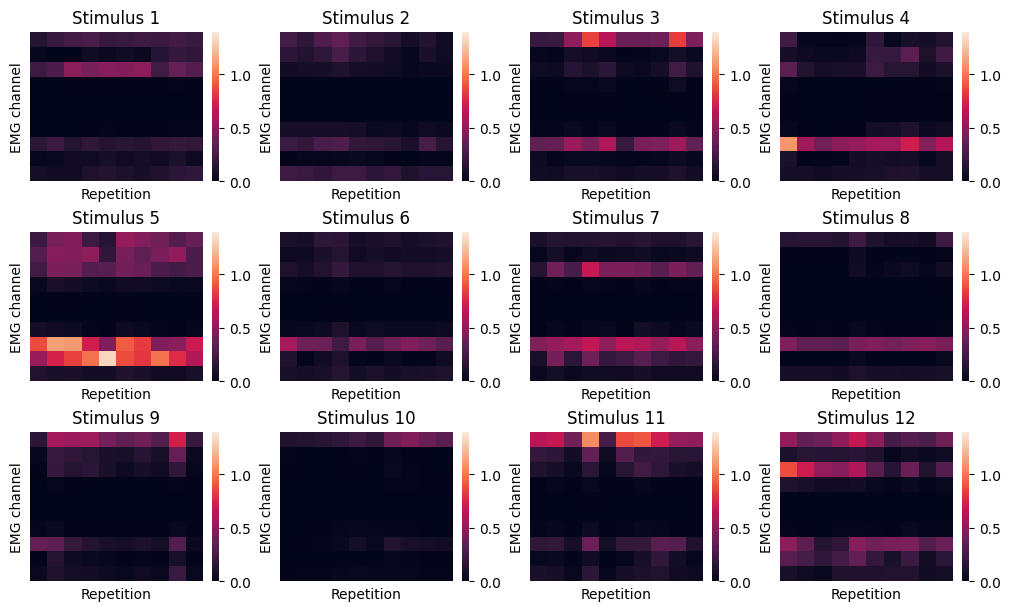

In [34]:
print(f"Number of channels: {n_channels}, Number of stimuli: {n_stimuli}, Number of repetitions: {n_repetitions}")
emg_average_activations = np.zeros((n_channels, n_stimuli, n_repetitions))
for stimuli_idx in range(n_stimuli):
    for repetition_idx in range(n_repetitions):
        #mean across time for each channel
        emg_average_activations[:, stimuli_idx, repetition_idx] = np.mean(emg_envelopes[stimuli_idx][repetition_idx], axis=0) 

fig, ax = plt.subplots(3, 4, figsize=(10, 6), constrained_layout=True, sharex=True, sharey=True)
ax = ax.ravel()

for stimuli_idx in range(n_stimuli):
    sns.heatmap(np.squeeze(emg_average_activations[:, stimuli_idx, :]), 
                ax=ax[stimuli_idx],
                vmin=0, 
                vmax=1.4,
                xticklabels=False, 
                yticklabels=False, 
                cbar = True)
    ax[stimuli_idx].title.set_text("Stimulus " + str(stimuli_idx + 1))
    ax[stimuli_idx].set_xlabel("Repetition")
    ax[stimuli_idx].set_ylabel("EMG channel")

In [35]:
def build_dataset_from_ninapro(emg, stimulus, repetition, features=[]):
    # Calculate the number of unique stimuli and repetitions, subtracting 1 to exclude the resting condition
    n_stimuli = np.unique(stimulus).size - 1
    n_repetitions = np.unique(repetition).size - 1
    # Total number of samples is the product of stimuli and repetitions
    n_samples = n_stimuli * n_repetitions
    
    # Number of channels in the EMG data
    n_channels = emg.shape[1]
    # Calculate the total number of features by summing the number of channels for each feature
    n_features = sum(n_channels for feature in features)
    
    # Initialize the dataset and labels arrays with zeros
    dataset = np.zeros((n_samples, n_features))
    labels = np.zeros(n_samples)
    current_sample_index = 0
    
    # Loop over each stimulus and repetition to extract features
    for i in range(n_stimuli):
        for j in range(n_repetitions):
            # Assign the label for the current sample
            labels[current_sample_index] = i + 1
            # Calculate the current sample index based on stimulus and repetition
            current_sample_index = i * n_repetitions + j
            current_feature_index = 0
            # Select the time steps corresponding to the current stimulus and repetition
            selected_tsteps = np.logical_and(stimulus == i + 1, repetition == j + 1).squeeze()
            
            # Loop over each feature function provided
            for feature in features:
                # Determine the indices in the dataset where the current feature will be stored
                selected_features = np.arange(current_feature_index, current_feature_index + n_channels)
                # Apply the feature function to the selected EMG data and store the result
                dataset[current_sample_index, selected_features] = feature(emg[selected_tsteps, :])
                # Update the feature index for the next feature
                current_feature_index += n_channels

            # Move to the next sample
            current_sample_index += 1
            
    # Return the constructed dataset and corresponding labels
    return dataset, labels

In [36]:

# Mean absolute value (MAV)
mav = lambda x: np.mean(np.abs(x), axis=0)
# Standard Deviation (STD)
std = lambda x: np.std(x, axis=0)
# Maximum absolute Value (MaxAV)
maxav = lambda x: np.max(np.abs(x), axis=0)
# Root mean square (RMS)
rms = lambda x: np.sqrt(np.mean(x**2, axis=0))
# Waveform length (WL)
wl = lambda x: np.sum(np.abs(np.diff(x, axis=0)), axis=0)
# Slope sign changes (SSC)
ssc = lambda x: np.sum((np.diff(x, axis=0)[:-1, :] * np.diff(x, axis=0)[1:, :]) < 0, axis=0)

# Additional features from the paper:
# Zero Crossings (ZC) with threshold to reduce noise sensitivity
def zc(x, th=0.01):
    # x: (T, C)
    dx = x[:-1, :] * x[1:, :]
    crossings = (dx < 0) & (np.abs(x[:-1, :]) > th) | (np.abs(x[1:, :]) > th)
    return np.sum(crossings, axis=0).astype(float)

# Willison Amplitude (WAMP) - counts of large amplitude differences
def wamp(x, th=0.02):
    return np.sum(np.abs(np.diff(x, axis=0)) > th, axis=0).astype(float)

# Simple FD features: mean frequency and median frequency per channel
def mean_freq(x, fs=2000):
    f, Pxx = welch(x, fs=fs, axis=0, nperseg=min(256, max(8, x.shape[0])))
    Psum = np.sum(Pxx, axis=0) + 1e-12
    return np.sum(f[:, None] * Pxx, axis=0) / Psum

def median_freq(x, fs=2000):
    f, Pxx = welch(x, fs=fs, axis=0, nperseg=min(256, max(8, x.shape[0])))
    Pcum = np.cumsum(Pxx, axis=0)
    total = Pcum[-1, :] + 1e-12
    med = np.zeros(x.shape[1])
    for c in range(x.shape[1]):
        idx = np.searchsorted(Pcum[:, c], total[c] / 2.0)
        med[c] = f[min(idx, f.size - 1)]
    return med

# Combine all features into a dict (keys are used later for selecting subsets)
all_features = {
    "mav": mav,
    "std": std,
    "maxav": maxav,
    "rms": rms,
    "wl": wl,
    "ssc": ssc,
    "zc": zc,
    "wamp": wamp,
    "mean_freq": mean_freq,
    "median_freq": median_freq,
}

#TODO: Feel free to add more features, e.g. frequency domain features. (See https://doi.org/10.3390/s19204596 and https://doi.org/10.1088/0967-3334/24/2/307)

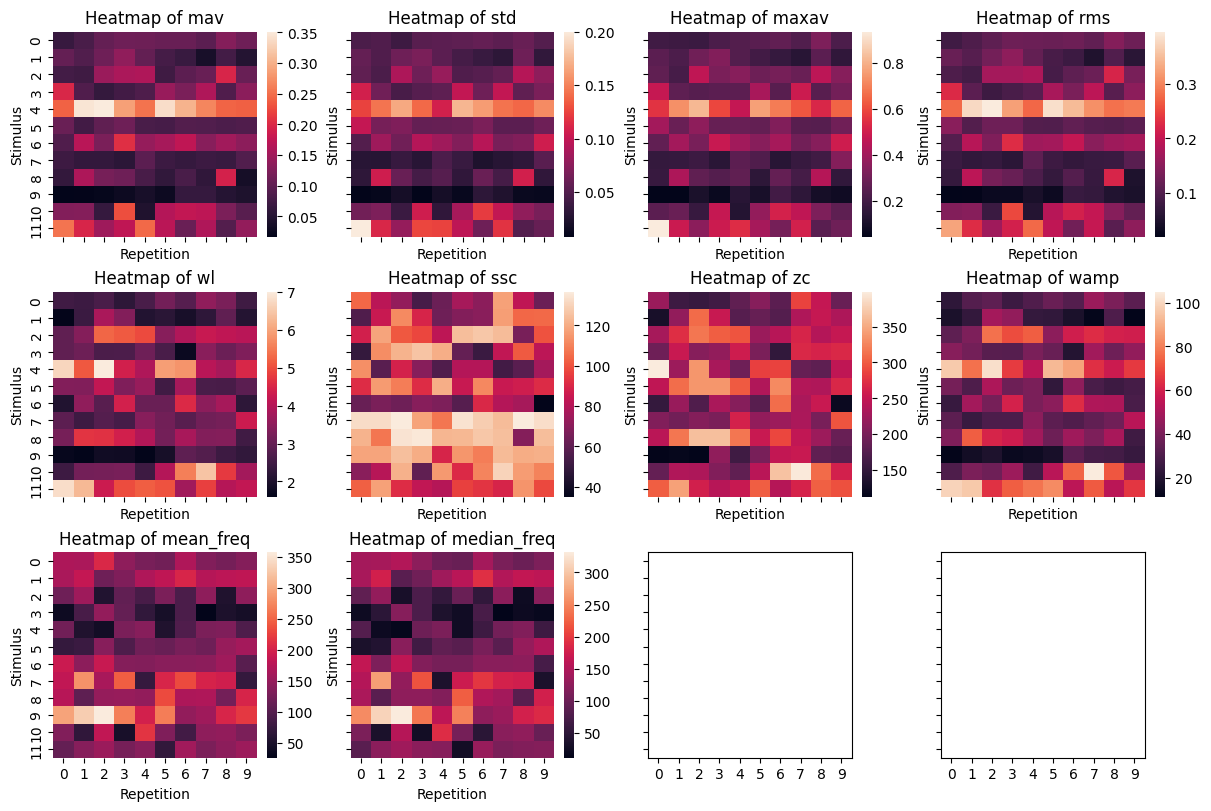

In [37]:
# Visualise all feature accross all trials as a heatmap

fig, ax = plt.subplots(3, 4, figsize=(12, 8), constrained_layout=True, sharex=True, sharey=True)
ax = ax.ravel()

for ax_idx, (feature_name, feature_func) in enumerate(all_features.items()):
    feature_values = []
    for stimuli_idx in range(n_stimuli):
        for repetition_idx in range(n_repetitions):
            mask = np.logical_and(stimulus == stimuli_idx + 1, repetition == repetition_idx + 1).flatten()
            feature_value = feature_func(emg[mask, :])
            feature_values.append(np.mean(feature_value))  # Mean across channels

    sns.heatmap(np.array(feature_values).reshape(n_stimuli, n_repetitions), annot=False, fmt=".2f", ax=ax[ax_idx])
    ax[ax_idx].set_title(f"Heatmap of {feature_name}")
    ax[ax_idx].set_xlabel("Repetition")
    ax[ax_idx].set_ylabel("Stimulus")
plt.show()

In [ ]:
# Leave-one-subject-out cross-validation (train on all subjects except one, test on the held-out subject)
features = list(all_features.values())
subjects = np.unique(all_data['subject_id'].to_numpy())

subject_accuracies = {}

for test_sub in subjects: 
    X_train_parts = []
    y_train_parts = []
    X_test, y_test = None, None

    for subj in subjects: 
        subj_df = all_data[all_data['subject_id'] == subj]
        emg_sub = subj_df[[c for c in subj_df.columns if c.startswith('emg_ch')]].values
        stimulus_sub = subj_df['stimulus'].to_numpy().squeeze()
        repetition_sub = subj_df['repetition'].to_numpy().squeeze()

        X_sub, y_sub = build_dataset_from_ninapro(emg=emg_sub,
                                                 stimulus=stimulus_sub,
                                                 repetition=repetition_sub,
                                                 features=features)

        if subj == test_sub:
            X_test, y_test = X_sub, y_sub
        else:
            X_train_parts.append(X_sub)
            y_train_parts.append(y_sub)

    # concatenate training data from all other subjects
    X_train = np.vstack(X_train_parts)
    y_train = np.hstack(y_train_parts)

    # scale features
    scaler = StandardScaler()
    X_train_z = scaler.fit_transform(X_train)
    X_test_z = scaler.transform(X_test)

    # train classifier
    clf = GradientBoostingClassifier(random_state=42)
    clf.fit(X_train_z, y_train)

    # evaluate
    y_pred = clf.predict(X_test_z)
    acc = accuracy_score(y_test, y_pred)
    subject_accuracies[int(test_sub)] = acc
    # print(f"Test subject {int(test_sub)} accuracy: {acc:.4f}")

# Summary
accuracies = np.array(list(subject_accuracies.values()))
print(f"\nMean leave-one-subject-out accuracy: {accuracies.mean():.4f}")

Test subject 1 accuracy: 0.3750
Test subject 2 accuracy: 0.0750
Test subject 2 accuracy: 0.0750
Test subject 3 accuracy: 0.4917
Test subject 3 accuracy: 0.4917
Test subject 4 accuracy: 0.4000
Test subject 4 accuracy: 0.4000
Test subject 5 accuracy: 0.4167
Test subject 5 accuracy: 0.4167
Test subject 6 accuracy: 0.3500
Test subject 6 accuracy: 0.3500
Test subject 7 accuracy: 0.4167
Test subject 7 accuracy: 0.4167
Test subject 8 accuracy: 0.4583
Test subject 8 accuracy: 0.4583
Test subject 9 accuracy: 0.2500
Test subject 9 accuracy: 0.2500
Test subject 10 accuracy: 0.4500
Test subject 10 accuracy: 0.4500
Test subject 11 accuracy: 0.3333
Test subject 11 accuracy: 0.3333
Test subject 12 accuracy: 0.3167
Test subject 12 accuracy: 0.3167
Test subject 13 accuracy: 0.3250
Test subject 13 accuracy: 0.3250
Test subject 14 accuracy: 0.3750
Test subject 14 accuracy: 0.3750
Test subject 15 accuracy: 0.4167
Test subject 15 accuracy: 0.4167
Test subject 16 accuracy: 0.5167
Test subject 16 accuracy: 0

In [39]:
print(max(accuracies))

0.6333333333333333


In [ ]:
# Analyze impact of training set size on classification performance
# Fix test subject as 27, vary number of training subjects from 1 to 26

test_subject = 27
training_subjects = [s for s in subjects if s != test_subject]

# Prepare test data once
test_df = all_data[all_data['subject_id'] == test_subject]
emg_test = test_df[[c for c in test_df.columns if c.startswith('emg_ch')]].values
stimulus_test = test_df['stimulus'].to_numpy().squeeze()
repetition_test = test_df['repetition'].to_numpy().squeeze()
X_test, y_test = build_dataset_from_ninapro(emg=emg_test,
                                           stimulus=stimulus_test,
                                           repetition=repetition_test,
                                           features=features)

# Track accuracy as we add more training subjects
n_training_subjects_list = []
accuracy_list = []

for n_train in range(1, len(training_subjects) + 1):
    # Use first n_train subjects for training
    train_subs = training_subjects[:n_train]
    
    X_train_parts = []
    y_train_parts = []
    
    for subj in train_subs:
        subj_df = all_data[all_data['subject_id'] == subj]
        emg_sub = subj_df[[c for c in subj_df.columns if c.startswith('emg_ch')]].values
        stimulus_sub = subj_df['stimulus'].to_numpy().squeeze()
        repetition_sub = subj_df['repetition'].to_numpy().squeeze()
        
        X_sub, y_sub = build_dataset_from_ninapro(emg=emg_sub,
                                                 stimulus=stimulus_sub,
                                                 repetition=repetition_sub,
                                                 features=features)
        X_train_parts.append(X_sub)
        y_train_parts.append(y_sub)
    
    # Concatenate training data
    X_train = np.vstack(X_train_parts)
    y_train = np.hstack(y_train_parts)
    
    # Scale features
    scaler = StandardScaler()
    X_train_z = scaler.fit_transform(X_train)
    X_test_z = scaler.transform(X_test)
    
    # Train classifier
    clf = GradientBoostingClassifier(random_state=42)
    clf.fit(X_train_z, y_train)
    
    # Evaluate on test subject
    y_pred = clf.predict(X_test_z)
    acc = accuracy_score(y_test, y_pred)
    
    n_training_subjects_list.append(n_train)
    accuracy_list.append(acc)
    print(f"Training subjects: {n_train:2d}, Test accuracy (subject {test_subject}): {acc:.4f}")

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(n_training_subjects_list, accuracy_list, marker='o', linewidth=2, markersize=6)
plt.xlabel('Number of Training Subjects', fontsize=12)
plt.ylabel('Test Accuracy (Subject 27)', fontsize=12)
plt.title('Impact of Training Set Size on Classification Performance', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nMaximum accuracy: {max(accuracy_list):.4f} with {n_training_subjects_list[np.argmax(accuracy_list)]} training subjects")
print(f"Final accuracy (all 26 subjects): {accuracy_list[-1]:.4f}")

Training subjects:  1, Test accuracy (subject 27): 0.0167
Training subjects:  2, Test accuracy (subject 27): 0.1500
Training subjects:  2, Test accuracy (subject 27): 0.1500
Training subjects:  3, Test accuracy (subject 27): 0.0583
Training subjects:  3, Test accuracy (subject 27): 0.0583
Training subjects:  4, Test accuracy (subject 27): 0.1167
Training subjects:  4, Test accuracy (subject 27): 0.1167
Training subjects:  5, Test accuracy (subject 27): 0.1167
Training subjects:  5, Test accuracy (subject 27): 0.1167
Training subjects:  6, Test accuracy (subject 27): 0.1583
Training subjects:  6, Test accuracy (subject 27): 0.1583
Training subjects:  7, Test accuracy (subject 27): 0.1500
Training subjects:  7, Test accuracy (subject 27): 0.1500
Training subjects:  8, Test accuracy (subject 27): 0.1833
Training subjects:  8, Test accuracy (subject 27): 0.1833
Training subjects:  9, Test accuracy (subject 27): 0.1750
Training subjects:  9, Test accuracy (subject 27): 0.1750
Training subje